# **Fase 1: PyTorch e EDOs**
**Objetivo:** dominar o *framework* que será usado em PINNs e conectar os gradientes automáticos (*autograds*) com EDOs.

**Conceitos-chave:**

### Sumário

*Etapa 1.1 PyTorch básico*

*Etapa 1.2 `torch.autograd.grad` vs `.backward()`*

*Etapa 1.3 Aproximação de funções*

**Etapa 1.4 Proto-PINN: EDO sem chamar de PINN**

*Mini-projeto 1: Reconstrução de $H(z)$ a partir de dados de cronômetros cósmicos*

## 1.4 — Proto-PINN: EDO sem chamar de PINN

Iremos aproximar a solução de uma EDO. A ideia é que treinar a rede para satisfazer a EDO, então, em vez da função de perda computar a distância para os dados observados, ela medirá o quanto a rede viola a EDO.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [11]:
x_dados = np.linspace(0, 2, 50).reshape(-1, 1)
x = torch.tensor(x_dados, dtype=torch.float, requires_grad=True)
Y = torch.exp(-x)

neuronios = 64

w1 = torch.randn((1, neuronios), dtype=torch.float, requires_grad=True)
b1 = torch.randn(neuronios, requires_grad=True)

w2 = torch.randn((neuronios, 1), dtype=torch.float, requires_grad=True)
b2 = torch.randn(1, dtype=torch.float, requires_grad=True)

epocas = 10000
eta = 0.0001

optimizer = torch.optim.Adam([w1, b1, w2, b2], lr=eta)

def loss_edo(der_u, u):
    return torch.mean((der_u+u)**2)

def loss_ci(u0):
    return (u0 - 1)**2

def forward(x, params, activation=None):
    w1, b1, w2, b2 = params

    h1 = x @ w1 + b1

    if activation is not None:
        if activation == 'relu':
            z1 = torch.nn.functional.relu(h1)
        elif activation == 'tanh':
            z1 = torch.nn.functional.tanh(h1)

    y = z1 @ w2 + b2

    return y

In [17]:
print(x.shape[0])

50


In [21]:
deru_pesos = torch.ones(x.shape)
x0 = torch.tensor([[0.0]])
params = [w1, b1, w2, b2]

for epoca in range(epocas):
    optimizer.zero_grad()

    u = forward(x, params, activation='tanh')
    der_u = torch.autograd.grad(u, x, grad_outputs=deru_pesos, retain_graph=True)[0]
    u0 = forward(x0, params, activation='tanh')

    loss = loss_edo(der_u, u) + loss_ci(u0)    
    loss.backward()
    optimizer.step()

    if (epoca+1)%500 == 0 or epoca == 0:
        print(30*'-'+f'\nÉpoca {epoca+1}:\n\nLoss = {loss}\n'+30*'-')

------------------------------
Época 1:

Loss = tensor([[42.7052]], grad_fn=<AddBackward0>)
------------------------------
------------------------------
Época 500:

Loss = tensor([[5.7613]], grad_fn=<AddBackward0>)
------------------------------
------------------------------
Época 1000:

Loss = tensor([[1.4065]], grad_fn=<AddBackward0>)
------------------------------
------------------------------
Época 1500:

Loss = tensor([[1.2768]], grad_fn=<AddBackward0>)
------------------------------
------------------------------
Época 2000:

Loss = tensor([[1.3279]], grad_fn=<AddBackward0>)
------------------------------
------------------------------
Época 2500:

Loss = tensor([[1.4139]], grad_fn=<AddBackward0>)
------------------------------
------------------------------
Época 3000:

Loss = tensor([[1.4965]], grad_fn=<AddBackward0>)
------------------------------
------------------------------
Época 3500:

Loss = tensor([[1.5017]], grad_fn=<AddBackward0>)
------------------------------
---

In [29]:
x_modelo = torch.ones((1000, 1))
torch.linspace(0, 2, 1000, out=x_modelo)
Y_modelo = torch.exp(-x_modelo)
y_modelo = forward(x_modelo, params, activation='tanh')

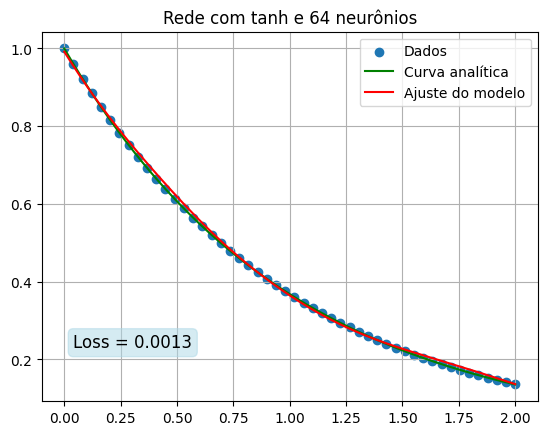

In [44]:
plt.scatter(x.detach().numpy(), Y.detach().numpy(), label='Dados')
plt.plot(x_modelo, Y_modelo.detach().numpy(), label='Curva analítica', color='green')
plt.plot(x_modelo, y_modelo.detach().numpy(), label='Ajuste do modelo', color='red')
plt.text(0.04, 0.23, 'Loss = 0.0013', fontsize=12, bbox=dict(boxstyle='round', fc='lightblue', ec='lightblue', alpha=0.5))
plt.title('Rede com tanh e 64 neurônios')
plt.legend()
plt.grid()
plt.show()